# `Cross-Correlation Special Case` Tutorial/Example

**Author**: Eishica Chand (email:[eishica.chand@students.iiserpune.ac.in](mailto:eishica.chand@students.iiserpune.ac.in))
\
**Date**: 22 July 2026\
**kNNpy version**: 0.0.1


<a name="imports" id="imports"></a>
## Imports and Setup


In [1]:
#Importing external libraries
import numpy as np
from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors
import readfof
import readgadget
import MAS_library as MASL
import os
import sys
import warnings
from scipy.special import factorial
from matplotlib.ticker import MaxNLocator
from scipy.spatial import cKDTree
import Pk_library as PKL

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('..'))           # '../../' is needed because the parent directory is two directories upstream of this test directory

if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf
from kNNpy.Auxiliary.TPCF import TracerField3D as tpcf       
from kNNpy import kNN_3D


<a name="plot-prefs" id="plot-prefs"></a>
### Plotting Preferences

We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `usetex=False` if you do not have $\LaTeX$ installed.


In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 15})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
c      =  ["#630A0A", "#0D156A", "#128712", "#2D8498", "#A41B92",  "#D76F33", "#5C558A", "#2F1728", '#D7A633', '#5C8A55', '#2F8A17']


## Functions

In [3]:
def decorrelated_field_kspace(field, threads):
    """
    Real field with same power spectrum as `field` but zero real-space
    cross-correlation with it: delta_x(k) = -i * delta(k) on the stored
    (kz >= 0) half-grid.

    Self-conjugate modes (kx,ky,kz each in {0, Ng/2}) have b(k)=0 by
    reality, so the -i rotation is undefined there consistently with
    realness -- these 8 modes are zeroed instead.
    """
    Ng = field.shape[0]
    middle = Ng // 2

    field_k = PKL.FFT3Dr_f(field, threads)

    field_xk = (-1j * field_k).astype(np.complex64)

    # zero all self-conjugate corner modes: (0 or Ng/2) in each axis
    for i in (0, middle):
        for j in (0, middle):
            for l in (0, middle):
                field_xk[i, j, l] = 0.0 + 0.0j

    field_x = PKL.IFFT3Dr_f(field_xk, threads)
    return field_x

In [4]:
def PoissonUniformCDFs(nbar, R_array, k):
    
    cdf_vals = np.zeros_like(R_array)

    for j, R in enumerate(R_array):
        lam     = (4/3) * np.pi * R**3 * nbar  # Poisson rate (expected count in volume)
        exp_lam = np.exp(-lam)
        total   = 0.0
        for i in range(k):  # P(N < k) = sum_{i=0}^{k-1} Poiss(i; λ)
            total += (lam**i / factorial(i, exact=False)) * exp_lam
        cdf_vals[j] = total

    return 1 - cdf_vals


## MAIN

### Query Points for CDFs Measurements

In [5]:
Lbox     =      1000.
QueryPos =      hf.create_query_3D('random', 256, Lbox)
QueryPos =      QueryPos.astype(np.float32)
QueryPos =      np.mod(QueryPos, Lbox) #periodic boundary conditions

print(f"Min and Max of the random query positions: {np.min(QueryPos,axis=0)}, {np.max(QueryPos,axis=0)}")
print(f"Average Inter Query Separation~", (Lbox**3/len(QueryPos))**(1/3))

Min and Max of the random query positions: [2.9420571e-05 0.0000000e+00 0.0000000e+00], [999.99994 999.99994 999.9998 ]
Average Inter Query Separation~ 3.9062499999999996


### Load Halos at $z=0$

In [6]:
DataPath='../kNNpy/Data'

snapnum, redshift = 4,0            # saving convention of Quijote
halo_dir =  f"{DataPath}/Quijote_simulations/fiducial_LR/0"

# read the halo catalogue
FoF = readfof.FoF_catalog(halo_dir, snapnum, long_ids=False,swap=False, SFR=False, read_IDs=False)

# get the properties of the halos
pos_halo      =     FoF.GroupPos/1e3            #Halo positions in Mpc/h
pos_halo      =     pos_halo.astype(np.float32)
mass_halo     =     FoF.GroupMass*1e10          #Halo masses in Msun/h
pos_halo      =     np.mod(pos_halo, Lbox)      # PBC

print(f"Informations about the halo catalogue at z={redshift}:")
print(f"Number of halos: {len(pos_halo)}")
print(f"Mass range: {np.min(mass_halo):.2e} - {np.max(mass_halo):.2e} Msun/h")

print(f"Position range: {np.min(pos_halo,axis=0)} - {np.max(pos_halo,axis=0)} Mpc/h")

Informations about the halo catalogue at z=0:
Number of halos: 406660
Mass range: 1.31e+13 - 5.47e+15 Msun/h
Position range: [0.00017787 0.00561007 0.00248465] - [999.996  999.9956 999.9966] Mpc/h


In [7]:
# Select Nh most massive halos for the analysis
Nh            =  100000
idx           =  np.argsort(mass_halo)[::-1][:Nh]
pos_halo_use  =  pos_halo[idx]
mass_halo_use =  mass_halo[idx]

print(f"Number of halos: {len(pos_halo_use)}")
print(f"Mass range: {np.min(mass_halo_use):.2e} - {np.max(mass_halo_use):.2e} Msun/h")
print(f"Position range: {np.min(pos_halo_use,axis=0)} - {np.max(pos_halo_use,axis=0)} Mpc/h")

del pos_halo, mass_halo, idx, mass_halo_use


Number of halos: 100000
Mass range: 4.66e+13 - 5.47e+15 Msun/h
Position range: [0.00849513 0.01377274 0.00263293] - [999.98865 999.99554 999.9966 ] Mpc/h


### Load Particle Positions at $z=0$ 

In [8]:
# Construct del_m
snapshot = f"{DataPath}/Quijote_simulations/fiducial_LR/0/snapdir_004/snap_004"
ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read header
header   = readgadget.header(snapshot)
Nall     = header.nall         #Total number of particles
redshift = header.redshift     #redshift of the snapshot
print(f"Snapshot redshift: {redshift:.2f}")

# read positions of the particles
pos_part = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
pos_part = pos_part.astype(np.float32)
pos_part = np.mod(pos_part, Lbox) #periodic boundary conditions

print(f"Snapshot read: {snapshot}")
print(f"Important Information:\nBoxSize = {Lbox:.2f} Mpc/h,\nNall = {Nall[1]},\nredshift = {redshift:.2f}")
print(f"Position range: {np.min(pos_part,axis=0)} - {np.max(pos_part,axis=0)} Mpc/h")


Snapshot redshift: 0.00
Snapshot read: ../kNNpy/Data/Quijote_simulations/fiducial_LR/0/snapdir_004/snap_004
Important Information:
BoxSize = 1000.00 Mpc/h,
Nall = 134217728,
redshift = 0.00
Position range: [0. 0. 0.] - [999.99994 999.99994 999.99994] Mpc/h


### Construct $\delta_m$

In [9]:
grid        =    512 
MAS         =   'CIC'   # mass-assigment scheme
verbose     =    True    # print information on progress

del_m   = np.zeros((grid,grid,grid), dtype=np.float32)

MASL.MA(pos_part, del_m, Lbox, MAS, verbose=verbose)
del_m /= np.mean(del_m, dtype=np.float64);  del_m -= 1.0

print(f"Mean and Standard Deviation:\ndelta_m: {np.mean(del_m):.5f}, {np.std(del_m):.5f}")

del pos_part



Using CIC mass assignment scheme
Time taken = 1.292 seconds

Mean and Standard Deviation:
delta_m: 0.00000, 3.89461


### Construct $\delta_X$ satisfying: $ \langle \delta_X\, \delta_m \rangle =0$

In [10]:
# Decorrelated matter field
del_X = decorrelated_field_kspace(del_m, threads=8)
print(f"Mean and Standard Deviation:\ndelta_X: {np.mean(del_X):.5f}, {np.std(del_X):.5f}")


Mean and Standard Deviation:
delta_X: -0.00000, 3.88402


<a name="poisson-bins" id="poisson-bins"></a>
### Theoretical Poisson CDFs and rbins


In [11]:
k_list  =   [1, 2]
r_max   =   35
num_r   =   25
nbar    =   Nh/(Lbox**3)
Rbins   =   np.zeros((len(k_list), num_r))

for i, k in enumerate(k_list):
    Rbins[i] = np.linspace(0, r_max, num_r)

Theoretical_Uniform_CDFs_test = []

for i, k in enumerate(k_list):
    Theoretical_Uniform_CDFs_test.append(PoissonUniformCDFs(nbar, Rbins[i], k))


In [12]:
low_bin  = np.zeros(len(k_list)).astype(int)
high_bin = np.zeros(len(k_list)).astype(int)

for i, k in enumerate(k_list):
    low_bin[i]  = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)
    print(f'{k}NN', '{:.2f}'.format(Rbins[i][low_bin[i]]), '{:.2f}'.format(Rbins[i][high_bin[i]]))

num_Rbins  = 10
Rbins_pick = np.zeros((len(k_list), num_Rbins))

for i, k in enumerate(k_list):
    Rbins_pick[i] = np.linspace(Rbins[i][low_bin[i]]*0.95, Rbins[i][high_bin[i]]*1.05, num_Rbins)

for i, k in enumerate(k_list):
    print(f'\nRadial bins for {k}NN-CDF:\n', Rbins_pick[i])
    print(f'\nNumber of bins for {k}NN-CDF: ', len(Rbins_pick[i]))


1NN 5.83 20.42
2NN 10.21 23.33

Radial bins for 1NN-CDF:
 [ 5.54166667  7.30787037  9.07407407 10.84027778 12.60648148 14.37268519
 16.13888889 17.90509259 19.6712963  21.4375    ]

Number of bins for 1NN-CDF:  10

Radial bins for 2NN-CDF:
 [ 9.69791667 11.34259259 12.98726852 14.63194444 16.27662037 17.9212963
 19.56597222 21.21064815 22.85532407 24.5       ]

Number of bins for 2NN-CDF:  10


### `2PCF`

#### Check

In [13]:
# Compute the 2PCF between del_m and del_mX

CF     = PKL.Xi(del_m, Lbox, MAS='CIC', axis=0, threads=8)
# get the attributes
r       =  CF.r3D      #radii in Mpc/h
xi_mm     =  CF.xi[:,0]  #correlation function (monopole)
del CF

CF     = PKL.Xi(del_X, Lbox, MAS='CIC', axis=0, threads=8)
xi_XX   = CF.xi[:,0]  #correlation function (monopole)
del CF

# compute cross-correlaton function of the two fields
CCF = PKL.XXi(del_m, del_X, Lbox, MAS=['CIC', 'CIC'], axis=0, threads=8)
xi_crossmX   = CCF.xi[:,0]  #monopole


Computing correlation function of the field...
Time to complete loop = 0.41
Time taken = 1.54 seconds

Computing correlation function of the field...
Time to complete loop = 0.39
Time taken = 1.57 seconds

Computing correlation function of the field...
Time to complete loop = 0.39
Time taken = 2.72 seconds


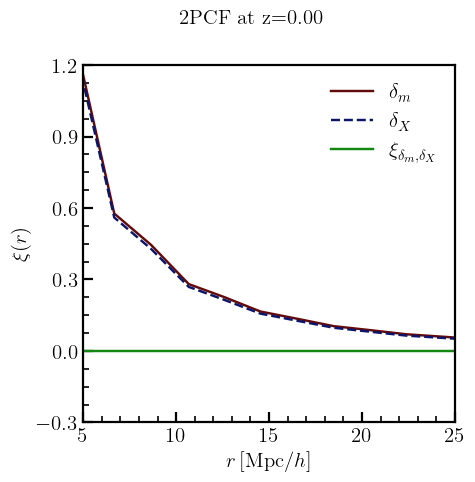

In [14]:
# plot the results
plt.figure(figsize=(5,5))
plt.plot(r, xi_mm, label=r'$\delta_m$', color=c[0], lw=1.75)
plt.plot(r, xi_XX, label=r'$\delta_{X}$', color=c[1], ls = '--', lw=1.75)
plt.plot(r, xi_crossmX, label=r'$\xi_{\delta_m,\delta_{X}}$', color=c[2], lw=1.75)
plt.xlabel(r'$r\,[{\rm Mpc}/h]$')
plt.ylabel(r'$\xi(r)$')
# plt.xscale('log')
# plt.yscale('log')
plt.xlim([5, 25])
plt.ylim([-0.3, 1.2])
plt.legend(frameon=False, fontsize=15)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.suptitle(f"2PCF at z={redshift:.2f}", x=0.53, y=0.97,fontsize=15)
plt.tight_layout()
plt.show()

#### Cross-correlation

In [15]:
# Keep these consistent if you change box_size/grid and re-run only this cell
grid_cell_size =    Lbox / grid
thickness      =    grid_cell_size

coords          =       (np.arange(grid) - grid // 2) * grid_cell_size
r_grid          =       hf.compute_r_grid(coords, grid)
r_2pcf          =       np.linspace(Rbins_pick[0][0], Rbins_pick[1][-1], 10)
print(f"r_2pcf: {r_2pcf}")
W_k_list        =       hf.make_W_k_list(r_2pcf, thickness, grid, r_grid, threads=8)

r_2pcf: [ 5.54166667  7.64814815  9.75462963 11.86111111 13.96759259 16.07407407
 18.18055556 20.28703704 22.39351852 24.5       ]


In [16]:
verbose = True
axis    =   0
MAS     = 'CIC'
threads =   8

In [17]:
help(tpcf.CrossCorr2pt)

Help on function CrossCorr2pt in module kNNpy.Auxiliary.TPCF.TracerField3D:

CrossCorr2pt(bins, pos, delta, boxsize, threads, W_k_list)
    Compute 2-point cross-correlation function between tracers and density field.
    Optimized: avoid memory copies, use in-place operations, reuse arrays.
    
    Parameters:
    -----------
    bins : array
        Radial bins for correlation function
    boxsize : float
        Size of simulation box
    pos : array
        Tracer positions (N, 3), must be float32
    delta : array
        Density field (ngrid, ngrid, ngrid)
    threads : int
        Number of threads for FFT
        
    Returns:
    --------
    xi : array
        Cross-correlation function values



In [18]:
tpcf_hm   = tpcf.CrossCorr2pt(r_2pcf, pos_halo_use, del_m, Lbox, threads, W_k_list)

In [19]:
tpcf_hX = tpcf.CrossCorr2pt(r_2pcf, pos_halo_use, del_X, Lbox, threads, W_k_list)

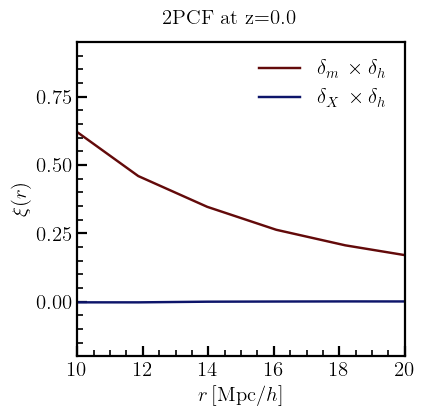

In [20]:
# plot the results
plt.figure(figsize=(4.5, 4.5))
plt.plot(r_2pcf, tpcf_hm, label=r'$\delta_m\, \times \delta_{h}$', color=c[0], lw=1.75)
plt.plot(r_2pcf, tpcf_hX, label=r'$\delta_{X}\, \times \delta_{h}$', color=c[1], ls = '-', lw=1.75)

plt.xlabel(r'$r\,[{\rm Mpc}/h]$')
plt.ylabel(r'$\xi(r)$')

plt.xlim([10, 20])
plt.ylim([-0.2, 0.95])
plt.legend(frameon=False, fontsize=15)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.suptitle(f"2PCF at z={redshift:.1f}", x=0.54, y=0.93,fontsize=15)
plt.tight_layout()
plt.show()

#### Pylians

In [21]:
del_h   = np.zeros((grid,grid,grid), dtype=np.float32)

MASL.MA(pos_halo_use, del_h, Lbox, MAS, verbose=verbose)
del_h /= np.mean(del_h, dtype=np.float64);  del_h -= 1.0

print(f"Mean and Standard Deviation:\ndelta_h: {np.mean(del_h):.5f}, {np.std(del_h):.5f}")



Using CIC mass assignment scheme
Time taken = 0.039 seconds

Mean and Standard Deviation:
delta_h: 0.00000, 19.99355


In [22]:
# compute cross-correlaton function of the two fields
CCF = PKL.XXi(del_h, del_m, Lbox, MAS, axis, threads)
# get the attributes
r        = CCF.r3D      #radii in Mpc/h
xxi_hm   = CCF.xi[:,0]  #monopole
del CCF

CCF = PKL.XXi(del_h, del_X, Lbox, MAS, axis, threads)
xxi_hX   = CCF.xi[:,0]  #monopole


Computing correlation function of the field...
Time to complete loop = 0.39
Time taken = 9.22 seconds

Computing correlation function of the field...
Time to complete loop = 0.39
Time taken = 6.59 seconds


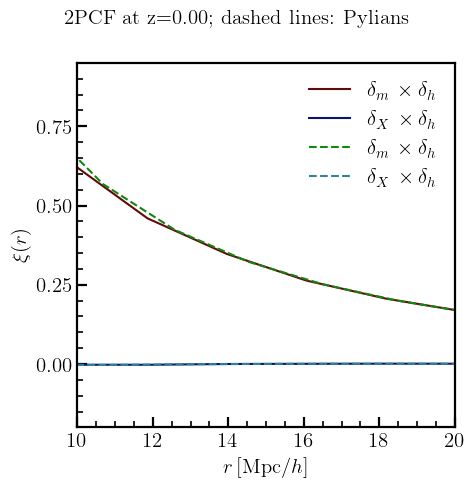

In [23]:

plt.figure(figsize=(5,5))

plt.plot(r_2pcf, tpcf_hm, label=r'$\delta_m\, \times \delta_{h}$', color=c[0], lw=1.5)
plt.plot(r_2pcf, tpcf_hX, label=r'$\delta_{X}\, \times \delta_{h}$', color=c[1], ls = '-', lw=1.5)

plt.plot(r, xxi_hm, label=r'$\delta_m\, \times \delta_{h}$', color=c[2], ls='--',lw=1.5)
plt.plot(r, xxi_hX, label=r'$\delta_{X}\, \times \delta_{h}$', color=c[3], ls = '--', lw=1.5)

plt.xlabel(r'$r\,[{\rm Mpc}/h]$')
plt.ylabel(r'$\xi(r)$')

plt.xlim([10, 20])
plt.ylim([-0.2, 0.95])
plt.legend(frameon=False, fontsize=15)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.suptitle(f"2PCF at z={redshift:.2f}; dashed lines: Pylians", fontsize=15)
plt.tight_layout()
plt.show()

### `kNN Tracer-Field Cross-Correlations`

In [24]:
#Print the API documentation for details on the function usage
help(kNN_3D.TracerFieldCross3D_DataVector)

Help on function TracerFieldCross3D_DataVector in module kNNpy.kNN_3D:

TracerFieldCross3D_DataVector(kList, RBins, BoxSize, QueryPos, TracerPosVector, Field, FieldConstPercThreshold, n_threads=1, ReturnSmoothedDict=False, Verbose=False)
    Returns 'data vectors' of the  the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ [refer to kNNpy.kNN_3D.TracerFieldCross for definitions] for $k$ in `kList` for multiple realisations of the given discrete tracer set [`TracerPosVector`] and a single realisation of the given continuous overdensity field (`Field`). Please refer to notes to understand why this might be useful.
        
    Parameters
    ----------
    kList : list of int
        List of nearest neighbours to compute. For example, if ``kList = [1, 2, 4]``, the first, second and fourth-nearest neighbour distributions will be computed.
    
    RBins : list of numpy float arrays
        List of radial distance arrays (in comoving Mpc/$h$), one for each value in `

In [25]:
delta_threshold = 75.0


In [26]:
# Recheck if within bounds
print(pos_halo_use.min(axis=0), pos_halo_use.max(axis=0))
print(QueryPos.min(axis=0), QueryPos.max(axis=0))

[0.00849513 0.01377274 0.00263293] [999.98865 999.99554 999.9966 ]


[2.9420571e-05 0.0000000e+00 0.0000000e+00] [999.99994 999.99994 999.9998 ]


In [27]:
# 1 del_m

kNN_results1    =  kNN_3D.TracerFieldCross3D(k_list, Rbins_pick, Lbox, QueryPos, pos_halo_use, del_m, delta_threshold)

AutoCDFs_m       = kNN_results1[0]       #The auto-CDFs
AutoPerc_m       = kNN_results1[1]       #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
JointCDFs_m      = kNN_results1[2]       #The halo-delm cross-CDF


In [28]:
# 1 del_X
kNN_results2 = kNN_3D.TracerFieldCross3D(k_list, Rbins_pick, Lbox, QueryPos, pos_halo_use, del_X, delta_threshold)

AutoCDFs_X       = kNN_results2[0]       #The auto-CDFs
AutoPerc_X       = kNN_results2[1]       #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
JointCDFs_X      = kNN_results2[2]       #The halo-delm cross-CDF


In [29]:
del kNN_results1, kNN_results2

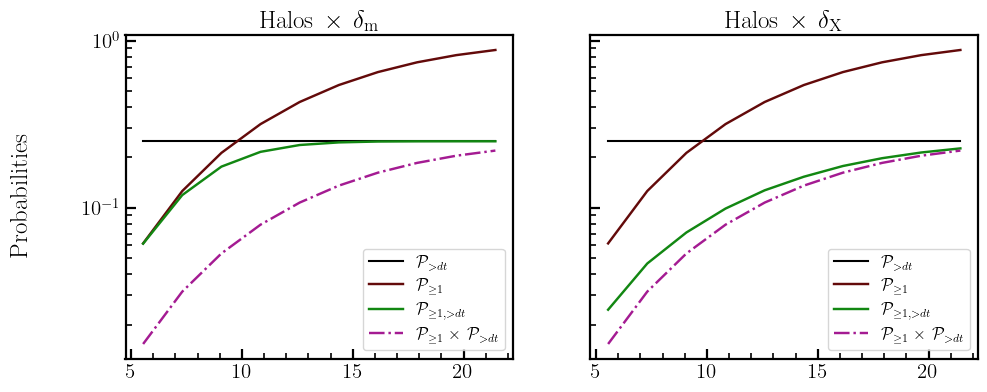

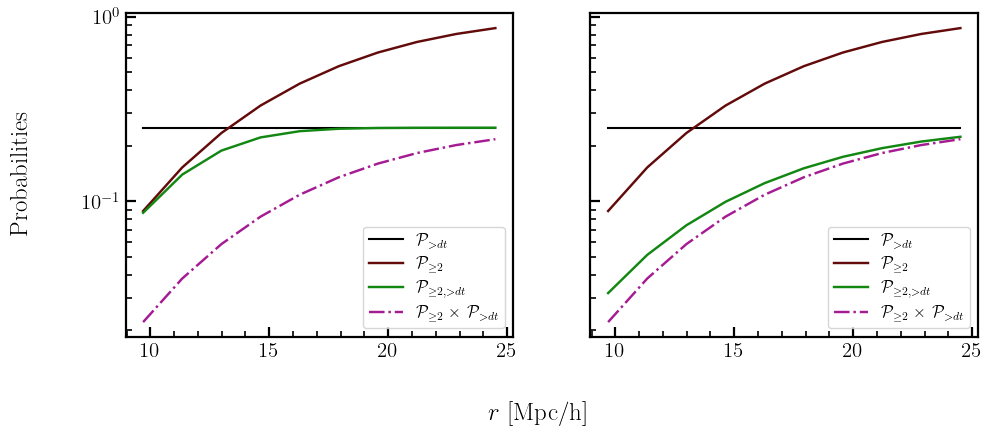

In [30]:
for i, k in enumerate(k_list):

    fig, (ax, ax1) = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
    
    ax.plot(Rbins_pick[i], AutoPerc_m[i], c='k', lw=1.5, label='$\\mathcal{{P}}_{{>dt}}$')
    ax.plot(Rbins_pick[i], AutoCDFs_m[i], c=c[0], lw=1.75, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax.plot(Rbins_pick[i], JointCDFs_m[i], c=c[2], lw=1.75, label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax.plot(Rbins_pick[i], AutoCDFs_m[i]*AutoPerc_m[i], c=c[4], ls='-.', lw=1.75, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax.legend(fontsize=12)
    if i==0: ax.set_title(r'$ \rm{Halos} \, \times \, \delta_m$')
    
    ax1.plot(Rbins_pick[i], AutoPerc_X[i], c='k', lw=1.5, label='$\\mathcal{{P}}_{{>dt}}$')
    ax1.plot(Rbins_pick[i], AutoCDFs_X[i], c=c[0], lw=1.75, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax1.plot(Rbins_pick[i], JointCDFs_X[i], c=c[2], lw=1.75, label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax1.plot(Rbins_pick[i], AutoCDFs_X[i]*AutoPerc_X[i], c=c[4], ls='-.', lw=1.75, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax1.legend(fontsize=12)
    if i==0: ax1.set_title(r'$ \rm{Halos} \, \times \, \delta_X$')

    if i==len(k_list)-1: fig.supxlabel(r'$r$ [Mpc/h]', y=-0.1)
    fig.supylabel('Probabilities')

    plt.yscale('log')
    plt.show()
    plt.close()

In [31]:
excess_mh  = hf.kNN_excess_cross_corr(AutoCDFs_m, AutoPerc_m, JointCDFs_m)
excess_Xh  = hf.kNN_excess_cross_corr(AutoCDFs_X, AutoPerc_X, JointCDFs_X)

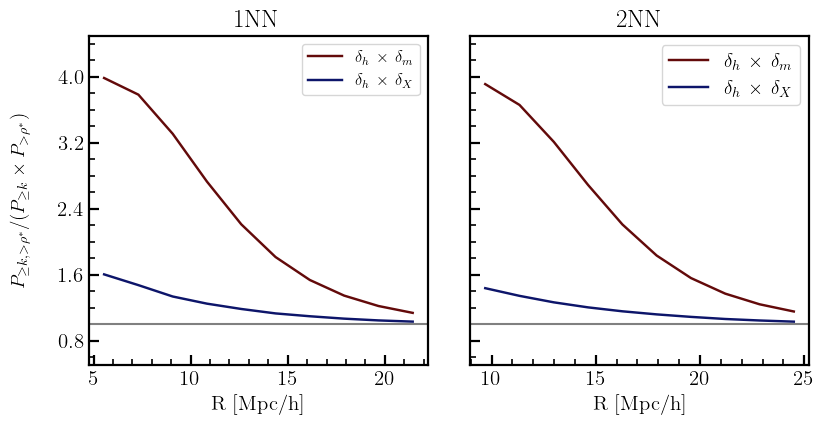

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 4.5), sharey=True)

for i, k in enumerate(k_list):

    ax[i].plot(Rbins_pick[i], excess_mh[i], color =c[0], lw=1.75, ls='-', label=r'$\delta_h \, \times \, \delta_m$')
    
    ax[i].plot(Rbins_pick[i], excess_Xh[i], color =c[1], lw=1.75, ls = '-', label=r'$\delta_h \, \times \, \delta_X$')
    
    ax[i].set_xlabel(r'R [Mpc/h]')
    ax[i].set_title(f'{k}NN')
    ax[i].legend(fontsize = 12)
    ax[i].yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[i].set_ylim([0.5, 4.5])
    ax[i].axhline(y=1.0, color='gray', ls='-', lw=1.5)

ax[0].set_ylabel(r'$P_{\geq k, > \rho^*}/ (P_{\geq k} \times P_{>\rho^*})$', labelpad = 20, fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout(w_pad=2)
plt.show()